In [94]:
# BLOC 1 : IMPORTATION DES BIBLIOTHÈQUES
# Manipulation et analyse des données
import pandas as pd
import numpy as np

# Visualisation des données
import matplotlib.pyplot as plt
import seaborn as sns

# Algorithmes de machine learning
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC

Cette cellule importe les bibliothèques nécessaires au projet, incluant les outils de manipulation des données, de visualisation et les algorithmes de Machine Learning utilisés pour l’entraînement et l’évaluation des modèles.

In [95]:
# BLOC 2 : CHARGEMENT ET NOMMAGE DES DONNÉES
# Chargement des datasets
train = pd.read_csv('Train.csv')
test  = pd.read_csv('Test.csv')

# Définition des noms de colonnes du dataset NSL-KDD
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "attack", "last_flag"
]

# Assignation des noms de colonnes aux deux datasets
train.columns = columns
test.columns  = columns

# Aperçu des premières lignes du dataset d'entraînement
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


Les Datasets chargés ne possaidaient pas de titre au niveau des colonnes, donc nous avons personnalisé en rajoutant des titres.

In [96]:
# BLOC 3 : INFORMATIONS GÉNÉRALES SUR LE DATASET
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  object 
 2   service                      125972 non-null  object 
 3   flag                         125972 non-null  object 
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 non-null  int64  
 13 

Cette étape permet d’examiner la structure du dataset, notamment le nombre d’observations, le nombre de variables, les types de données et la présence éventuelle de valeurs manquantes.

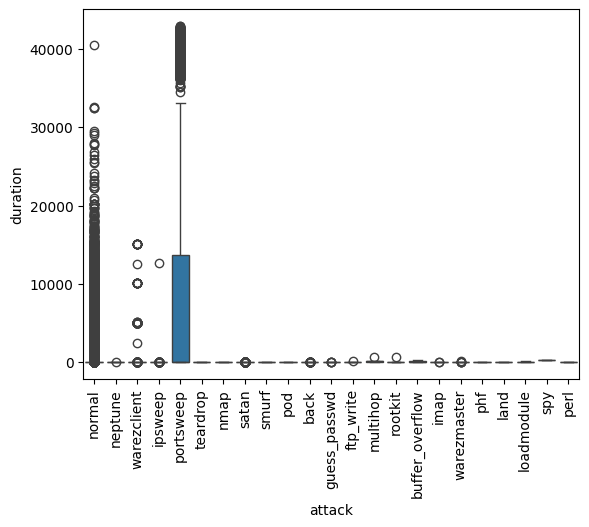

In [97]:
# BLOC 4 : BOXPLOT — DURÉE PAR TYPE D'ATTAQUE
sns.boxplot(data=train, x="attack", y="duration")
plt.xticks(rotation=90)  # Rotation des étiquettes pour la lisibilité
plt.show()

On a crée un boxplot

Le boxplot permet de voir la durée de la moyenne des connexions, la variabilité et les valeurs extrêmes & ainsi comparer facilement la distribution d'une variable pour plusieurs catégories.

Sur notre graphique : visualisation permet d’analyser la distribution de la durée des connexions réseau pour chaque type d’attaque. Le boxplot met en évidence les différences de comportement entre le trafic normal et les différentes attaques.


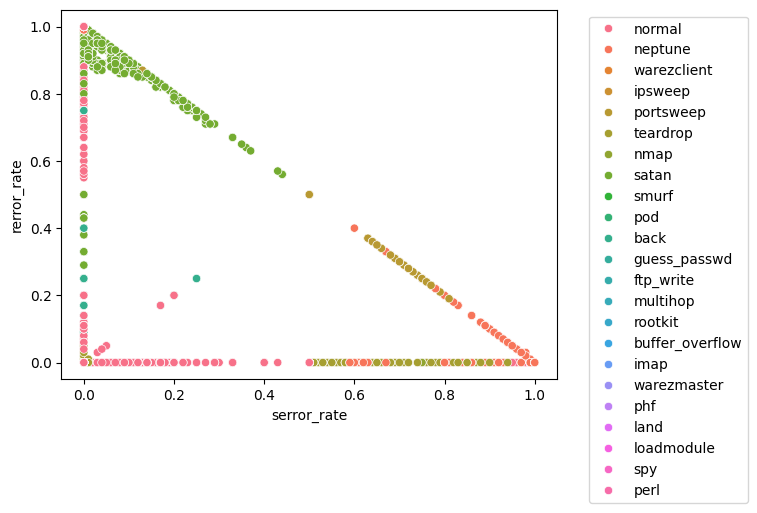

In [98]:
# BLOC 5 : NUAGE DE POINTS — TAUX D'ERREURS SYN vs RST
sns.scatterplot(data=train, x="serror_rate", y="rerror_rate", hue="attack")

# Déplacement de la légende hors du graphique pour ne pas masquer les données
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Le nuage de points représenté est composé de chaque point qui definit une connexion réseau dans le dataset.

La valeur 0 est le trafic normal tandis que la valeur 1 représente les attaques.

Ce graphique nous permet de voir comment les attaques & le trafic normal se repartissent dans l'espace des variables.

Si les points se séparent bien alors les variables sont informatives. Si ils sont mélangés alors elles sont moins utiles.

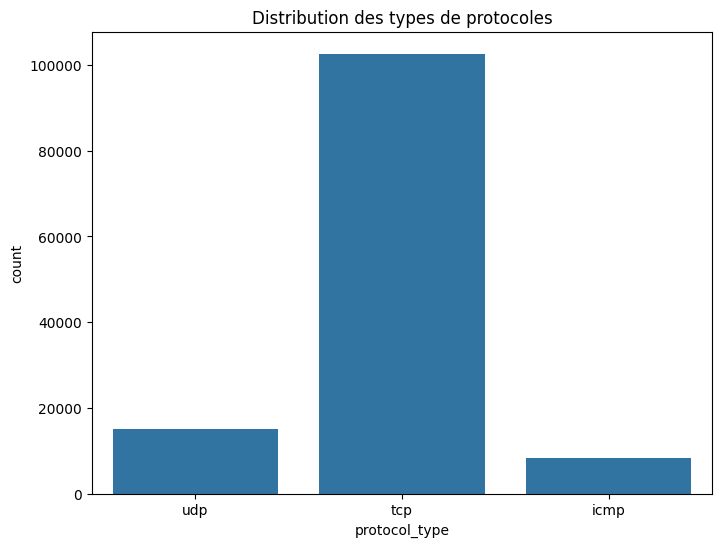

In [99]:
# BLOC 6 : DISTRIBUTION DES TYPES DE PROTOCOLES
plt.figure(figsize=(8, 6))
sns.countplot(x='protocol_type', data=train)
plt.title('Distribution des types de protocoles')
plt.show()

Cette visualisation permet d’analyser la distribution des différents protocoles réseau dans le dataset.

On observe que le protocole TCP est le plus utilisé, ce qui est cohérent avec le fonctionnement du trafic réseau dans de nombreuses applications.

/tmp/ipykernel_2190/3820344966.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


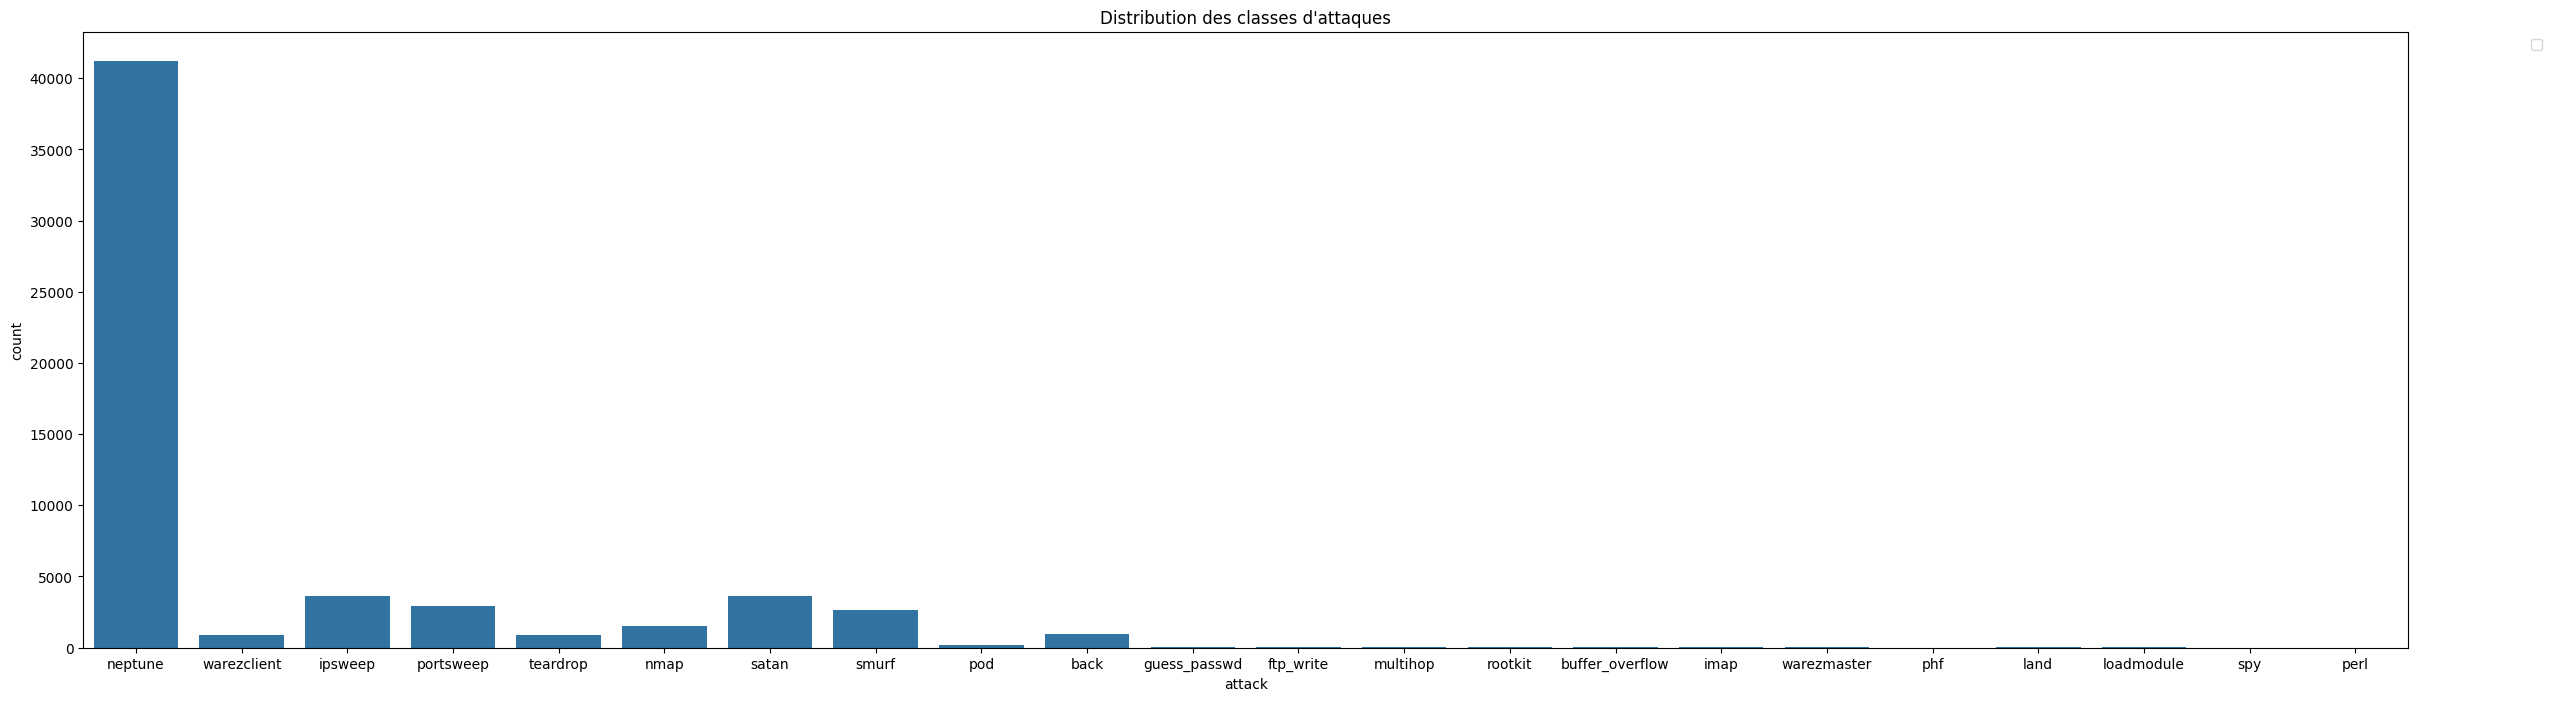

In [100]:
# BLOC 7 : DISTRIBUTION DES CLASSES D'ATTAQUES
# Filtrer uniquement les connexions anormales (attaques)
train_filtered = train[train['attack'] != 'normal']

# Création du graphique de distribution des attaques
plt.figure(figsize=(30, 8))
sns.countplot(x='attack', data=train_filtered)
plt.title("Distribution des classes d'attaques")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Cette visualisation permet d’observer la distribution des différents types d’attaques présents dans le dataset.

On constate que certaines classes sont beaucoup plus fréquentes que d’autres notamment neptune, on en conclut que le dataset est déséquilibré au niveau des types d'attaques.

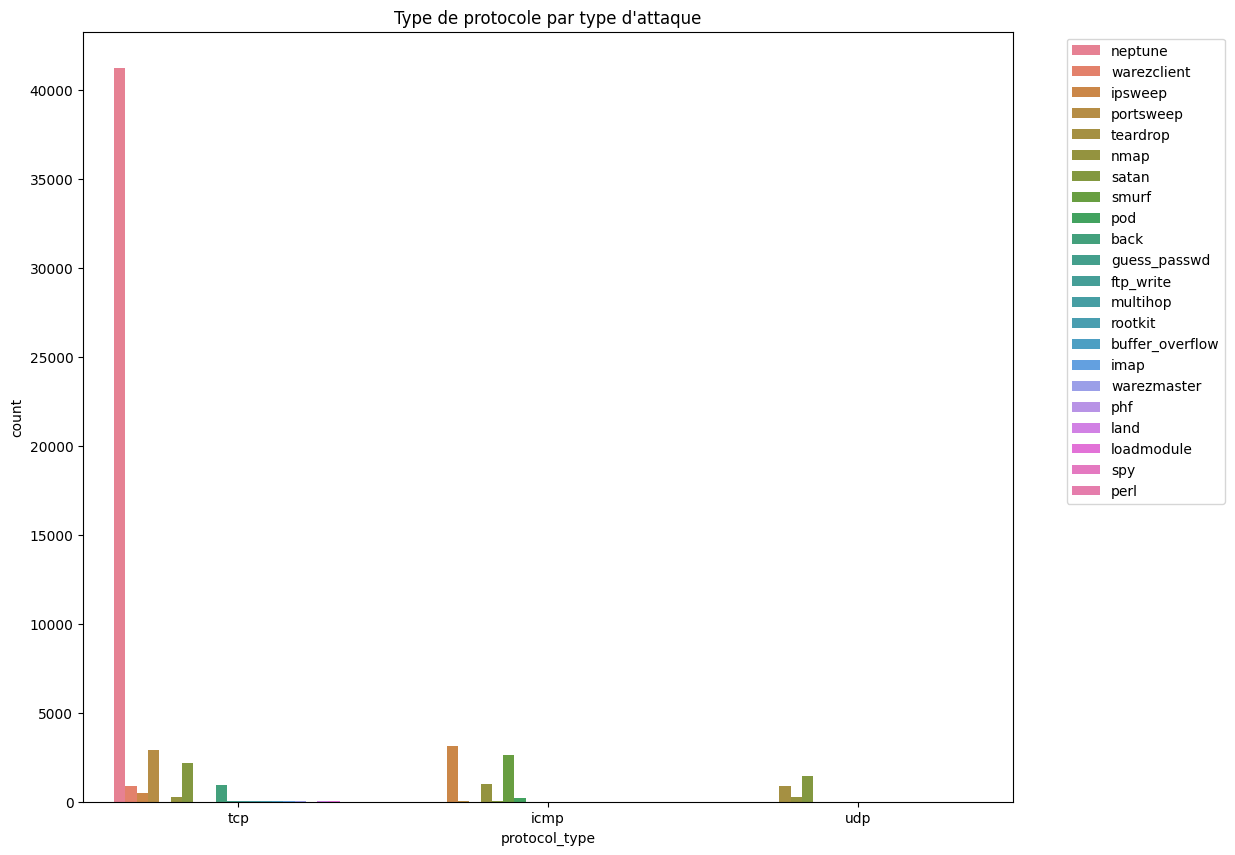

In [101]:
# BLOC 8 : PROTOCOLE PAR TYPE D'ATTAQUE
# Filtrer uniquement les attaques (exclure le trafic normal)
train_filtered = train[train['attack'] != 'normal']

# Graphique croisant protocole et type d'attaque
plt.figure(figsize=(12, 10))
sns.countplot(data=train_filtered, x='protocol_type', hue='attack')
plt.title("Type de protocole par type d'attaque")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

On voit que la plupart des attaques passent par TCP, mais certaines attaques spécifiques utilisent ICMP ou UDP, ce qui aide le modèle à les différencier.

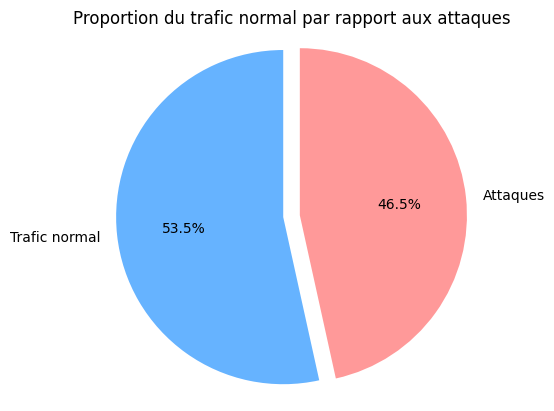

In [102]:
# BLOC 9 : DIAGRAMME CIRCULAIRE — TRAFIC NORMAL VS ATTAQUES
# Comptage de chaque type d'attaque
attack_counts = train['attack'].value_counts()

# Calcul de la proportion de trafic normal
normal_count      = attack_counts.get('normal', 0)
total_count       = attack_counts.sum()
proportion_normal = normal_count / total_count

# Paramètres du graphique en camembert
labels  = ['Trafic normal', 'Attaques']
sizes   = [proportion_normal, 1 - proportion_normal]
colors  = ['#66b3ff', '#ff9999']
explode = (0.1, 0)  # Mise en relief du secteur "normal"

plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90)
plt.axis('equal')  # Assurer un rendu circulaire
plt.title('Proportion du trafic normal par rapport aux attaques')
plt.show()

Cette visualisation présente la proportion de connexions normales et d’attaques dans le dataset. Elle permet de vérifier l’équilibre des classes avant l’entraînement des modèles de Machine Learning.

On peut constater que le dataset est globalement équilibré entre le trafic normal & les attaques.

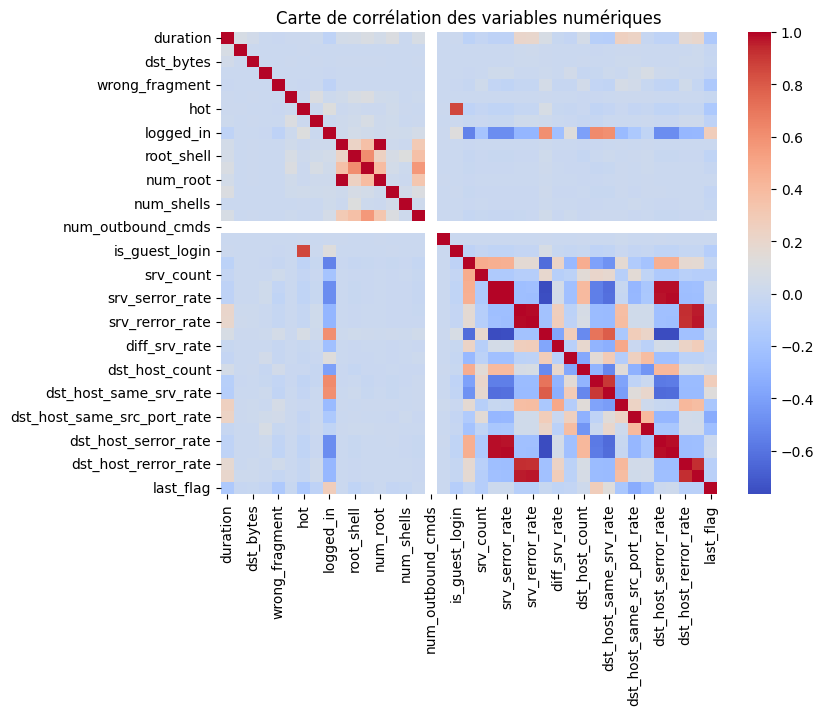

In [103]:
# BLOC 10 : CARTE DE CORRÉLATION (HEATMAP)
plt.figure(figsize=(8, 6))
corr = train.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Carte de corrélation des variables numériques')
plt.show()

Ce heatmap permet de visualiser les corrélations entre les différentes variables numériques du dataset. Elle aide à identifier les relations fortes entre certaines caractéristiques et à détecter d’éventuelles redondances dans les données.

Cette analyse nous a permet de comprendre les relations entre les variables et d’identifier les caractéristiques qui apportent une information similaire.


In [104]:
# BLOC 11 : VÉRIFICATION DES VALEURS MANQUANTES
missing_values_train = train.isnull().sum()
missing_values_test  = test.isnull().sum()

print("Valeurs manquantes dans les données d'entraînement :\n", missing_values_train)
print("----------------------------------------------")
print("Valeurs manquantes dans les données de test :\n", missing_values_test)

Valeurs manquantes dans les données d'entraînement :
 duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate         

In [105]:
# BLOC 12 : ENCODAGE DES VARIABLES CATÉGORIELLES
# Colonnes catégorielles à encoder
categorical_cols = ['protocol_type', 'service', 'flag']
label_encoder    = LabelEncoder()

# Encodage : on entraîne sur train et on transforme train et test
for col in categorical_cols:
    train[col] = label_encoder.fit_transform(train[col])
    test[col]  = label_encoder.transform(test[col])

# Binarisation de la colonne cible : normal=0, attaque=1
train['attack'] = np.where(train['attack'] == 'normal', 0, 1)
test['attack']  = np.where(test['attack']  == 'normal', 0, 1)

train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag
0,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,0,15
1,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,1,19
2,0,1,24,9,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,0,21
3,0,1,24,9,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0,21
4,0,1,49,1,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,1,21




Cette cellule fait deux transformations importantes pour le Machine Learning :

Encoder les variables catégorielles & Transformer la variable cible en classification binaire

Car les modèles de Machine Learning ne peuvent pas utiliser des données textuelles, donc on doit les convertir en valeurs numériques.


In [106]:
# BLOC 13 : NORMALISATION DES VARIABLES NUMÉRIQUES
# Sauvegarde du dataset original avant normalisation (pour comparaison)
train_original = train.copy()

# Identification des colonnes numériques (hors cible et catégorielles)
numerical_cols = [col for col in train.columns if col not in ['attack'] + categorical_cols]

# Calcul des paramètres de normalisation sur les données d'entraînement uniquement
scaler = StandardScaler().fit(train[numerical_cols])
means  = train[numerical_cols].mean()
stds   = train[numerical_cols].std()

# Application de la normalisation sur train et test
train[numerical_cols] = (train[numerical_cols] - means) / stds
test[numerical_cols]  = (test[numerical_cols]  - means) / stds

train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag
0,-0.110249,2,44,9,-0.007737,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,-1.161030,2.736829,2.367719,-0.289103,-0.639533,-0.624872,-0.387633,-0.376387,0,-1.965539
1,-0.110249,1,49,5,-0.007762,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,-0.938288,-0.174418,-0.480192,-0.289103,1.608744,1.618940,-0.387633,-0.376387,1,-0.219967
2,-0.110249,1,24,9,-0.007723,-0.002891,-0.014089,-0.089486,-0.007736,-0.095076,...,1.066389,-0.439077,-0.383105,0.066249,-0.572085,-0.602434,-0.387633,-0.345084,0,0.652820
3,-0.110249,1,24,9,-0.007728,-0.004814,-0.014089,-0.089486,-0.007736,-0.095076,...,1.066389,-0.439077,-0.480192,-0.289103,-0.639533,-0.624872,-0.387633,-0.376387,0,0.652820
4,-0.110249,1,49,1,-0.007762,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,-1.005111,-0.068555,-0.480192,-0.289103,-0.639533,-0.624872,2.874386,2.753890,1,0.652820


Ici on applique la standarisation aux variables numérques du dataset afin de mettre toute les caractéristiques sur la même échelle.

Car les algorithmes de Machines Learning sont sensibles à la variation de grandes et petites valeurs lors de l'apprentissage.


In [107]:
# BLOC 14 : SUPPRESSION D'UNE COLONNE CONSTANTE
train = train.drop(columns=['num_outbound_cmds'])
test  = test.drop(columns=['num_outbound_cmds'])

train.info()
train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  float64
 1   protocol_type                125972 non-null  int64  
 2   service                      125972 non-null  int64  
 3   flag                         125972 non-null  int64  
 4   src_bytes                    125972 non-null  float64
 5   dst_bytes                    125972 non-null  float64
 6   land                         125972 non-null  float64
 7   wrong_fragment               125972 non-null  float64
 8   urgent                       125972 non-null  float64
 9   hot                          125972 non-null  float64
 10  num_failed_logins            125972 non-null  float64
 11  logged_in                    125972 non-null  float64
 12  num_compromised              125972 non-null  float64
 13 

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag
0,-0.110249,2,44,9,-0.007737,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,-1.161030,2.736829,2.367719,-0.289103,-0.639533,-0.624872,-0.387633,-0.376387,0,-1.965539
1,-0.110249,1,49,5,-0.007762,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,-0.938288,-0.174418,-0.480192,-0.289103,1.608744,1.618940,-0.387633,-0.376387,1,-0.219967
2,-0.110249,1,24,9,-0.007723,-0.002891,-0.014089,-0.089486,-0.007736,-0.095076,...,1.066389,-0.439077,-0.383105,0.066249,-0.572085,-0.602434,-0.387633,-0.345084,0,0.652820
3,-0.110249,1,24,9,-0.007728,-0.004814,-0.014089,-0.089486,-0.007736,-0.095076,...,1.066389,-0.439077,-0.480192,-0.289103,-0.639533,-0.624872,-0.387633,-0.376387,0,0.652820
4,-0.110249,1,49,1,-0.007762,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,-1.005111,-0.068555,-0.480192,-0.289103,-0.639533,-0.624872,2.874386,2.753890,1,0.652820


Certaines variables peuvent être constantes ou non informatives. Elles n’apportent aucune information utile au modèle et peuvent être supprimées pour simplifier le dataset.

Nous avons analysé les colonnes du dataset et observé que la variable num_outbound_cmds avait toujours la valeur 0, ce qui signifie qu’elle ne contient aucune information exploitable donc cette colonne à été supprimé !


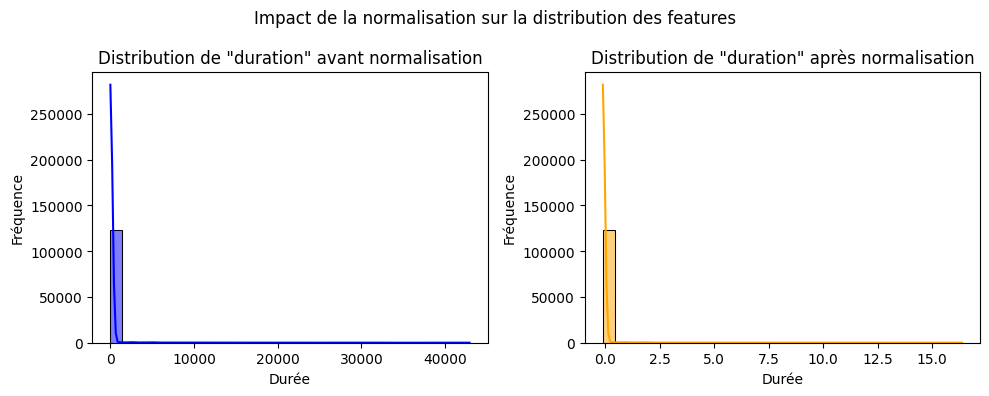

In [108]:
# BLOC 15 : IMPACT DE LA NORMALISATION SUR UNE VARIABLE
feature = 'duration'
plt.figure(figsize=(10, 4))

# Distribution avant normalisation
plt.subplot(1, 2, 1)
sns.histplot(train_original[feature], bins=30, color='blue', kde=True)
plt.xlabel('Durée')
plt.ylabel('Fréquence')
plt.title('Distribution de "duration" avant normalisation')

# Distribution après normalisation
plt.subplot(1, 2, 2)
sns.histplot(train[feature], bins=30, color='orange', kde=True)
plt.xlabel('Durée')
plt.ylabel('Fréquence')
plt.title('Distribution de "duration" après normalisation')

plt.suptitle('Impact de la normalisation sur la distribution des features')
plt.tight_layout()
plt.show()

On doit comparer la distribution de la variable "Duration" avant & après standarisation.

Le But est de vérifier que la standarisation à bien modifié l'echelle des données tout en conservant la forme de la dustribution.

La comparaison entre les 2 graphiques montre que la transfprmation modifie l'echelle des valeurs mais la forme de la distribution est conservé.

Top 11 features sélectionnées : Index(['logged_in', 'same_srv_rate', 'dst_host_same_srv_rate',
       'dst_host_serror_rate', 'serror_rate', 'srv_serror_rate', 'flag',
       'last_flag', 'dst_host_srv_count', 'protocol_type',
       'dst_host_srv_serror_rate'],
      dtype='object')


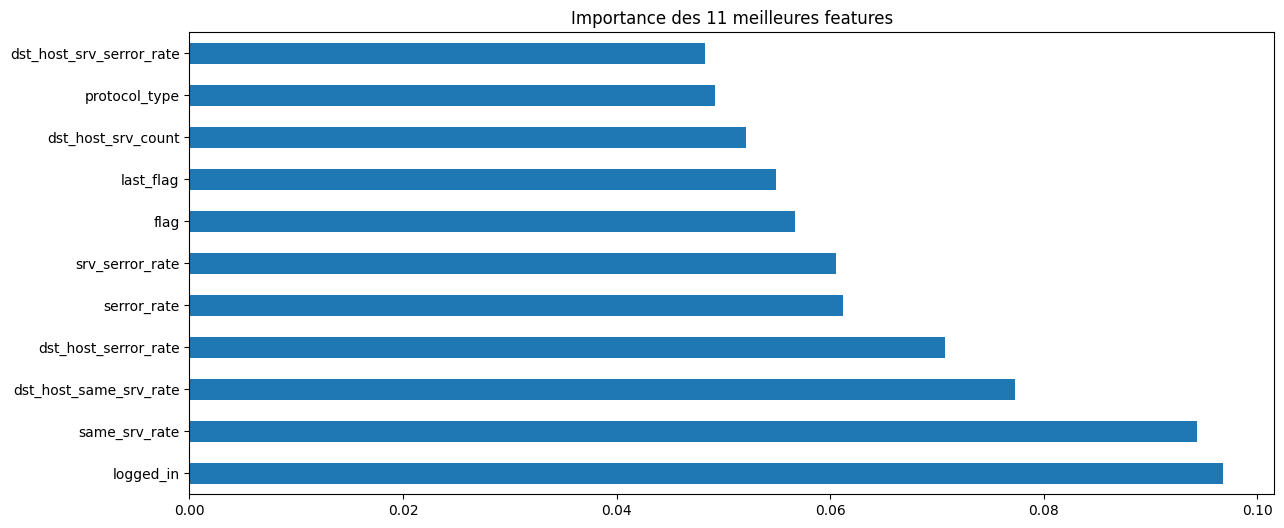

Classes cibles : [0 1]


In [109]:

# BLOC 16 : SÉLECTION DES FEATURES IMPORTANTES

# Séparation des features et de la variable cible
X_train = train.drop('attack', axis=1)
y_train = train['attack']

# Entraînement du modèle de sélection de features
model = ExtraTreesClassifier(n_estimators=100)
model.fit(X_train, y_train)

# Identification et affichage des 11 features les plus importantes
feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
top_features     = feat_importances.nlargest(11).index
print("Top 11 features sélectionnées :", top_features)

# Visualisation sous forme de barres horizontales
plt.figure(figsize=(14, 6))
feat_importances.nlargest(11).plot(kind='barh')
plt.title('Importance des 11 meilleures features')
plt.show()

print("Classes cibles :", y_train.unique())

Un modèle ExtraTreesClassifier permet d’estimer automatiquement l’importance des variables grâce à un ensemble d’arbres de décision.

Donc nous l'avons utilisé pour évaluer l’importance de chaque caractéristique dans la prédiction des attaques. Les 11 variables les plus importantes ont ensuite été sélectionnées afin de réduire la dimension du dataset et d’améliorer l’efficacité des modèles de classification.

In [110]:
# BLOC 17 : RÉDUCTION DU DATASET AUX FEATURES SÉLECTIONNÉES
train = train[top_features.tolist() + ['attack']]
test  = test[top_features.tolist()  + ['attack']]

train.head()

,logged_in,same_srv_rate,dst_host_same_srv_rate,dst_host_serror_rate,serror_rate,srv_serror_rate,flag,last_flag,dst_host_srv_count,protocol_type,dst_host_srv_serror_rate,attack
0,-0.809264,-1.321415,-1.161030,-0.639533,-0.637210,-0.631930,9,-1.965539,-1.035689,2,-0.624872,0
1,-0.809264,-1.389655,-0.938288,1.608744,1.602649,1.605089,5,-0.219967,-0.809859,1,1.618940,1
2,1.235681,0.771285,1.066389,-0.572085,-0.189238,-0.184526,9,0.652820,1.258741,1,-0.602434,0
3,1.235681,0.771285,1.066389,-0.639533,-0.637210,-0.631930,9,0.652820,1.258741,1,-0.624872,0
4,-0.809264,-1.139441,-1.005111,-0.639533,-0.637210,-0.631930,1,0.652820,-0.873091,1,-0.624872,1


Après avoir identifié les caractéristiques les plus importantes à l’aide du modèle ExtraTreesClassifier, nous avons réduit le dataset pour conserver uniquement ces variables pertinentes ainsi que la variable cible.

Certaines variables peuvent être redondantes ou peu informatives. Garder uniquement les variables les plus importantes permet d’améliorer la performance et de réduire la complexité du modèle.

In [111]:

# BLOC 18 : PRÉPARATION DES TABLEAUX NUMPY POUR L'ENTRAÎNEMENT
X_test  = test[top_features.tolist()].values
y_test  = test['attack'].values
X_train = train[top_features.tolist()].values
y_train = train['attack'].values

print("Étiquettes d'entraînement :", y_train)

Étiquettes d'entraînement : [0 1 0 ... 0 1 0]


In [112]:
# BLOC 19 : MODÈLE 1 — RANDOM FOREST
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Précision Random Forest :", accuracy_score(y_test, rf_pred))

Précision Random Forest : 0.8643481346759526


In [113]:

# BLOC 20 : MODÈLE 2 — NAIVE BAYES (GAUSSIEN)
nb = GaussianNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Précision Naive Bayes :", accuracy_score(y_test, nb_pred))

Précision Naive Bayes : 0.8025994765559153


In [114]:

# BLOC 21 : MODÈLE 3 — SUPPORT VECTOR MACHINE (SVM)

svm = SVC()
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("Précision SVM :", accuracy_score(y_test, svm_pred))

Précision SVM : 0.897351727809076


In [115]:
# BLOC 22 : MODÈLE 4 — K-NEAREST NEIGHBORS (KNN)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("Précision KNN :", accuracy_score(y_test, knn_pred))

Précision KNN : 0.8898993035532095


In [116]:
# BLOC 23 : MODÈLE 5 — RÉGRESSION LOGISTIQUE
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Précision Régression Logistique :", accuracy_score(y_test, lr_pred))

Précision Régression Logistique : 0.8893669875349333


In [117]:
import joblib

# Sauvegarder les modèles
joblib.dump(rf, "rf_model.pkl")
joblib.dump(nb, "nb_model.pkl")
joblib.dump(svm, "svm_model.pkl")
joblib.dump(knn, "knn_model.pkl")
joblib.dump(lr, "lr_model.pkl")

# Sauvegarder les features utilisées
joblib.dump(top_features.tolist(), "selected_features.pkl")

print("Modèles + features sauvegardés")

Modèles + features sauvegardés


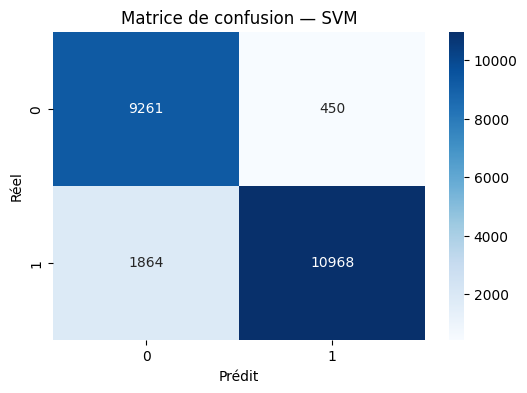

In [118]:

# BLOC 24 : MATRICE DE CONFUSION DU MODÈLE SVM

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion — SVM")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

In [119]:
from sklearn.metrics import classification_report, accuracy_score

# RANDOM FOREST
print("=== RANDOM FOREST ===")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

# NAIVE BAYES
print("=== NAIVE BAYES ===")
print("Accuracy :", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

# SVM
print("=== SVM ===")
print("Accuracy :", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

# KNN
print("=== KNN ===")
print("Accuracy :", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

# REGRESSION LOGISTIQUE
print("=== LOGISTIC REGRESSION ===")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))


=== RANDOM FOREST ===
Accuracy : 0.8643481346759526
              precision    recall  f1-score   support

           0       0.77      0.97      0.86      9711
           1       0.97      0.78      0.87     12832

    accuracy                           0.86     22543
   macro avg       0.87      0.88      0.86     22543
weighted avg       0.89      0.86      0.86     22543

=== NAIVE BAYES ===
Accuracy : 0.8025994765559153
              precision    recall  f1-score   support

           0       0.70      0.96      0.81      9711
           1       0.96      0.68      0.80     12832

    accuracy                           0.80     22543
   macro avg       0.83      0.82      0.80     22543
weighted avg       0.85      0.80      0.80     22543

=== SVM ===
Accuracy : 0.897351727809076
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      9711
           1       0.96      0.85      0.90     12832

    accuracy                           

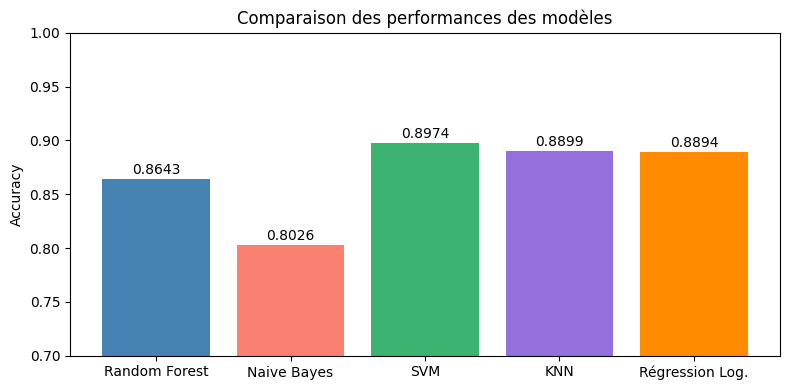

In [120]:

# BLOC 26: COMPARAISON DES MODÈLES
models   = ["Random Forest", "Naive Bayes", "SVM", "KNN", "Régression Log."]
accuracy = [
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, svm_pred),
    accuracy_score(y_test, knn_pred),
    accuracy_score(y_test, lr_pred)
]

colors = ['steelblue', 'salmon', 'mediumseagreen', 'mediumpurple', 'darkorange']

plt.figure(figsize=(8, 4))
bars = plt.bar(models, accuracy, color=colors)
plt.title("Comparaison des performances des modèles")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1.0)

# Affichage de la valeur exacte au-dessus de chaque barre
for bar, acc in zip(bars, accuracy):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.002,
             f"{acc:.4f}",
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [121]:
import joblib

# Sauvegarder les modèles
joblib.dump(rf, "rf_model.pkl")
joblib.dump(nb, "nb_model.pkl")
joblib.dump(svm, "svm_model.pkl")
joblib.dump(knn, "knn_model.pkl")
joblib.dump(lr, "lr_model.pkl")

# Sauvegarder les features utilisées
joblib.dump(top_features.tolist(), "selected_features.pkl")

print("Modèles + features sauvegardés")

Modèles + features sauvegardés
